In [1]:
import os
import random
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

/home/mrmin50000/github/aie-environment/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
dataset = load_dataset("emotion")  # уже содержит train/validation/test
print(dataset)
print("Классы:", dataset["train"].features["label"].names)

for split in ["train", "validation", "test"]:
    sample = dataset[split][0]
    print(f"[{split}] Label: {sample['label']} | Text: {sample['text'][:80]}...")


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
[train] Label: 0 | Text: i didnt feel humiliated...
[validation] Label: 0 | Text: im feeling quite sad and sorry for myself but ill snap out of it soon...
[test] Label: 0 | Text: im feeling rather rotten so im not very ambitious right now...


In [3]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

texts = [
    "i am so happy today",
    "this makes me really angry",
    "i feel terrified about tomorrow"
]

for t in texts:
    enc = tokenizer(t, padding="max_length", max_length=32, truncation=True, return_tensors="pt")
    print(f"Text: {t}")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(enc['input_ids'][0])}")
    print(f"input_ids: {enc['input_ids'].squeeze().tolist()[:10]}...")
    print(f"attention_mask: {enc['attention_mask'].squeeze().tolist()[:10]}...")
    print(f"Special tokens: [CLS], [SEP], padding_id={tokenizer.pad_token_id}\n")

Text: i am so happy today
Tokens: ['[CLS]', 'i', 'am', 'so', 'happy', 'today', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2572, 2061, 3407, 2651, 102, 0, 0, 0]...
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]...
Special tokens: [CLS], [SEP], padding_id=0

Text: this makes me really angry
Tokens: ['[CLS]', 'this', 'makes', 'me', 'really', 'angry', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 2023, 3084, 2033, 2428, 4854, 102, 0, 0, 0]...
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]...
Special tokens: [CLS], [SEP], padding_id=0

Text: i feel terrified about tomorrow
Tokens

In [4]:
from transformers import pipeline

pipe = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment-latest", device=0 if DEVICE.type=="cuda" else -1)

test_texts = [
    "I love this course!",
    "I'm really worried about the exam.",
    "Nothing special happened today."
]

for txt in test_texts:
    res = pipe(txt)
    print(f"Text: {txt} -> {res}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 33009.21it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text: I love this course! -> [{'label': 'positive', 'score': 0.9801685810089111}]
Text: I'm really worried about the exam. -> [{'label': 'negative', 'score': 0.8008147478103638}]
Text: Nothing special happened today. -> [{'label': 'neutral', 'score': 0.661215603351593}]


In [7]:
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./hw13_training",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=1,
    weight_decay=0.01,
    seed=SEED,
    logging_steps=50,
    fp16=DEVICE.type=="cuda"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3728.77it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.236917,0.192388,0.929500,0.904887


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.55it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=1000, training_loss=0.5038893194198608, metrics={'train_runtime': 1856.5653, 'train_samples_per_second': 8.618, 'train_steps_per_second': 0.539, 'total_flos': 386556911661312.0, 'train_loss': 0.5038893194198608, 'epoch': 1.0})

/home/mrmin50000/github/aie-environment/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Accuracy: 0.9245 | Test F1-macro: 0.8829


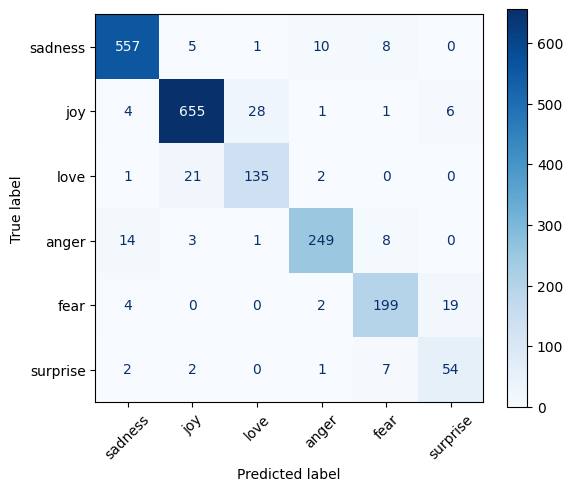

,text,true_label,pred_label
0,i feel terrific in every one of them,joy,joy
1,i smiled at him feeling his longing and said m...,love,love
2,i feel a little nervous i go to the gym,fear,fear
3,i feel like it might just be ok,joy,joy
4,i am going to actively learn more about these ...,joy,joy
5,when we rearranged furniture in our flat and g...,anger,sadness
6,i cant do strappy shoes at work i just feel we...,fear,surprise
7,i feel so thrilled to have three such distingu...,joy,joy


Количество ошибок в выборке: 2
🔹 True: anger | Pred: sadness | Text: when we rearranged furniture in our flat and got stuck in a chair...
🔹 True: fear | Pred: surprise | Text: i cant do strappy shoes at work i just feel weird so i took these off thrifted ninewest...


In [8]:
test_preds = trainer.predict(tokenized_datasets["test"])
y_true = test_preds.label_ids
y_pred = np.argmax(test_preds.predictions, axis=1)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")
print(f"Test Accuracy: {acc:.4f} | Test F1-macro: {f1:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
labels_names = dataset["train"].features["label"].names
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.tight_layout()
os.makedirs("artifacts", exist_ok=True)
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()

# Примеры предсказаний
idx_samples = random.sample(range(len(dataset["test"])), 8)
rows = []
for i in idx_samples:
    txt = dataset["test"][i]["text"]
    t = dataset["test"][i]["label"]
    p = y_pred[i]
    rows.append({"text": txt, "true_label": labels_names[t], "pred_label": labels_names[p]})

df_pred = pd.DataFrame(rows)
df_pred.to_csv("artifacts/sample_predictions.csv", index=False)
display(df_pred)

errors = df_pred[df_pred["true_label"] != df_pred["pred_label"]]
print(f"Количество ошибок в выборке: {len(errors)}")
for _, row in errors.head(3).iterrows():
    print(f"🔹 True: {row['true_label']} | Pred: {row['pred_label']} | Text: {row['text'][:100]}...")